#Import the necessary libraries

In [6]:
!pip install interpret

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from interpret import show
from interpret.glassbox import ExplainableBoostingRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

#Create the DataFrame

In [8]:
data_dict = {
    'Size_sqft': [1400,1600,1700,1875,1100,2200,1450,1250,2000,2100,
                  1550,1800,2400,1300,1950,1500,1750,2250,1150,2300],

    'Bedrooms': [3,3,4,4,2,5,3,2,4,4,
                  3,4,5,2,4,3,3,4,2,5],

    'Age_Years': [12,8,15,5,20,3,18,25,7,10,
                  14,9,2,22,6,16,11,4,30,1],

    'Distance_to_City': [8.5,6.2,10.1,4.5,12.0,3.2,9.8,14.2,5.1,6.0,
                         7.4,5.8,2.5,13.0,4.0,8.8,6.7,3.9,15.0,2.0],

    'School_Rating': [8,9,7,9,6,10,7,5,8,9,
                      8,9,10,6,9,7,8,10,5,10],

    'Crime_Index': [22,18,30,15,40,10,28,45,17,16,
                     24,20,8,38,14,26,21,12,50,7],

    'Price_USD': [320000,385000,340000,455000,240000,
                  590000,310000,210000,470000,510000,
                  350000,420000,650000,235000,490000,
                  330000,395000,540000,190000,710000]
}

In [9]:
df = pd.DataFrame(data_dict)

#Set the Features and the Target variables

In [10]:
X = df.drop('Price_USD', axis=1)

In [11]:
y = df['Price_USD']

#Exploratory Data Analysis

In [12]:
df.head()

,Size_sqft,Bedrooms,Age_Years,Distance_to_City,School_Rating,Crime_Index,Price_USD
0,1400,3,12,8.5,8,22,320000
1,1600,3,8,6.2,9,18,385000
2,1700,4,15,10.1,7,30,340000
3,1875,4,5,4.5,9,15,455000
4,1100,2,20,12.0,6,40,240000


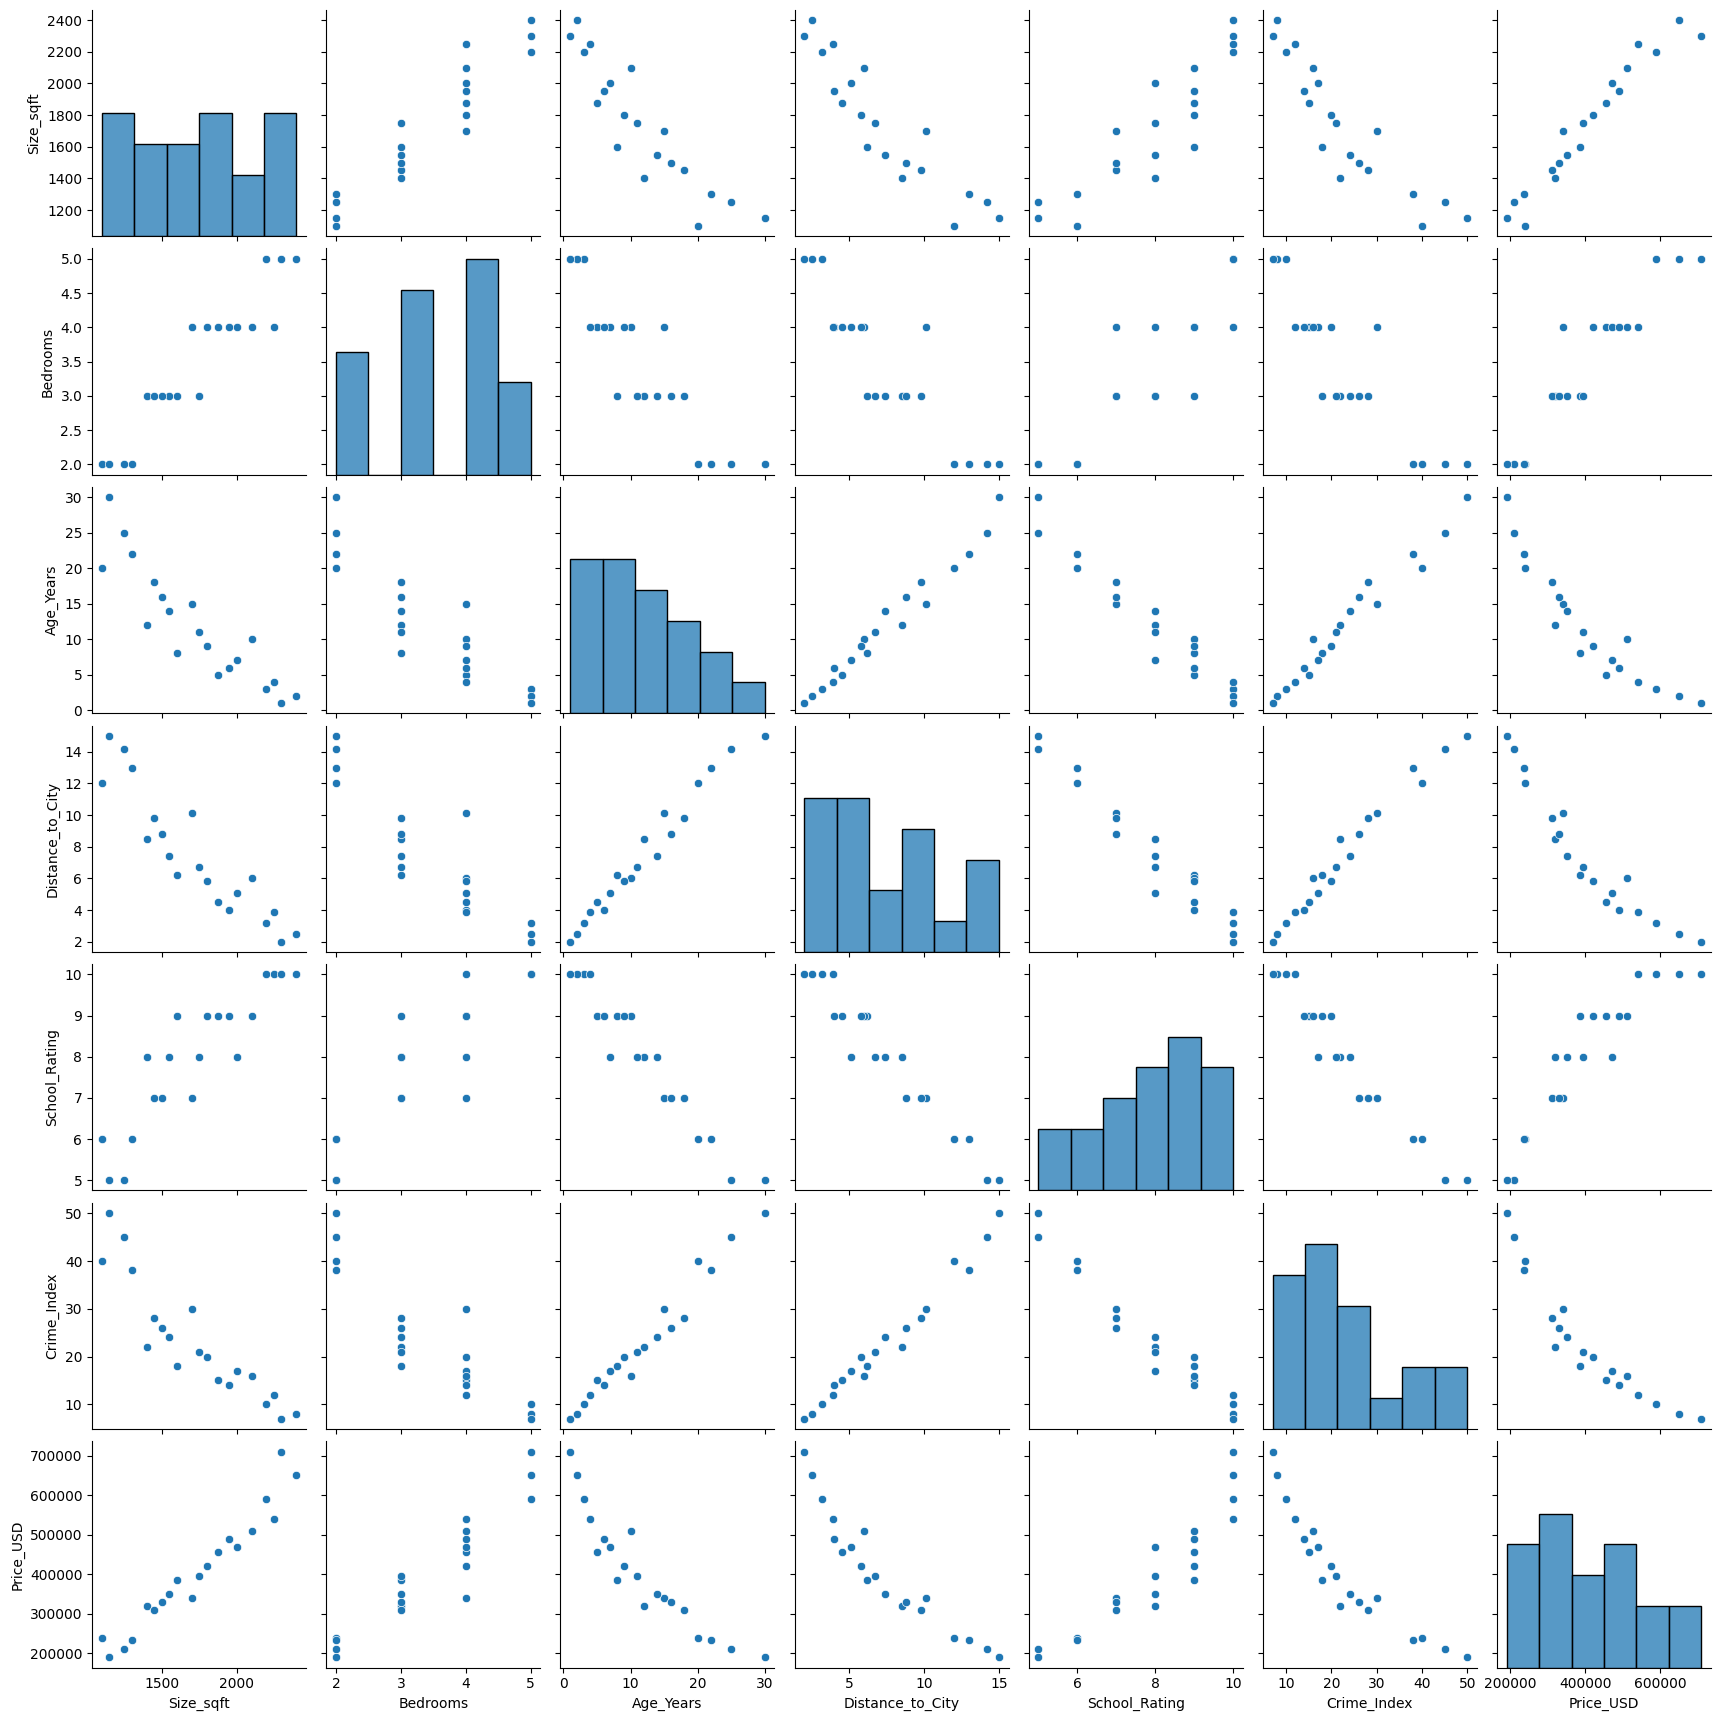

In [13]:
sns.pairplot(df)

<Axes: xlabel='Size_sqft', ylabel='Price_USD'>

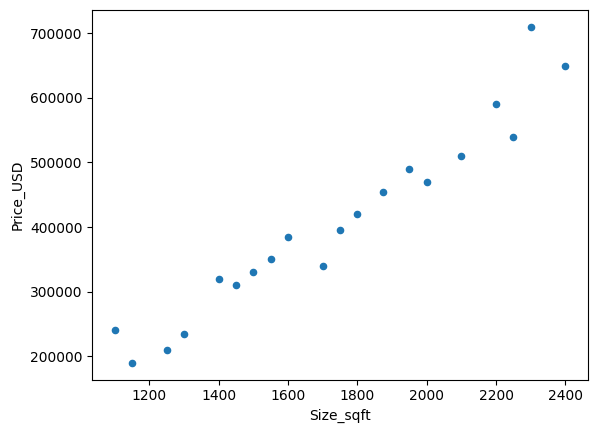

In [14]:
df.plot.scatter(x='Size_sqft', y='Price_USD')

<Axes: xlabel='Bedrooms', ylabel='Price_USD'>

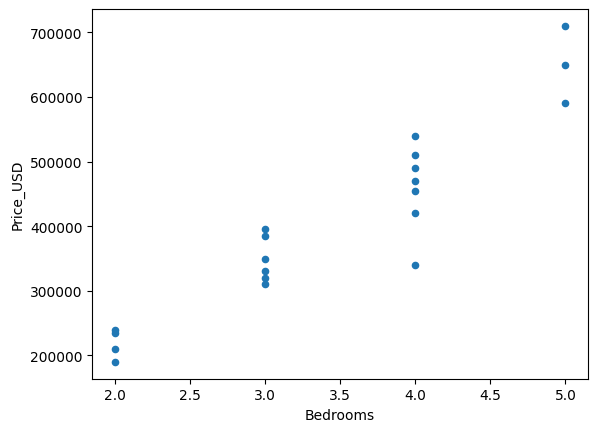

In [15]:
df.plot.scatter('Bedrooms', 'Price_USD')

<Axes: xlabel='Age_Years', ylabel='Price_USD'>

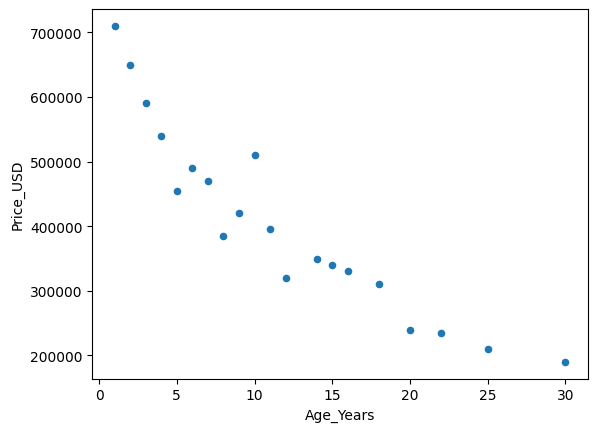

In [16]:
df.plot.scatter('Age_Years', 'Price_USD')

<Axes: xlabel='Distance_to_City', ylabel='Price_USD'>

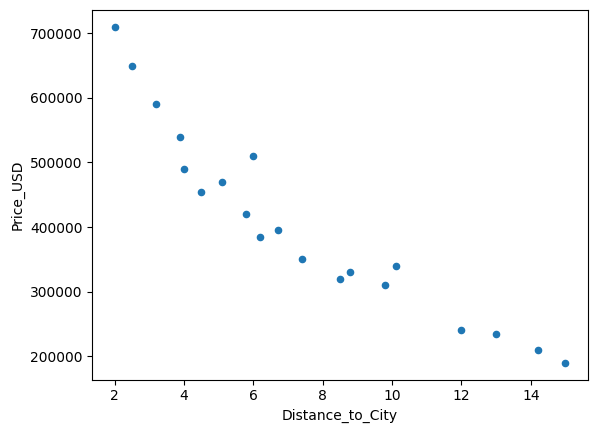

In [17]:
df.plot.scatter('Distance_to_City', 'Price_USD')

<Axes: xlabel='School_Rating', ylabel='Price_USD'>

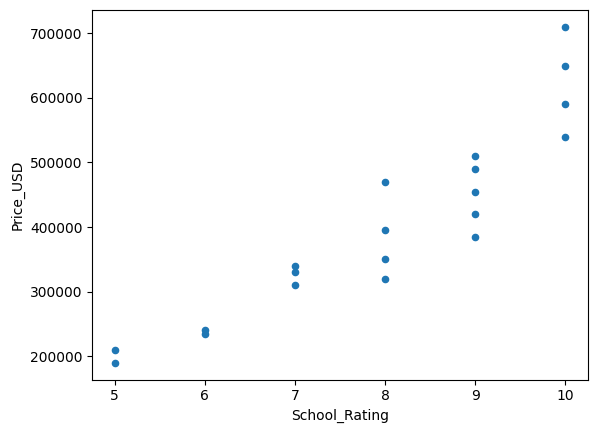

In [18]:
df.plot.scatter('School_Rating', 'Price_USD')

<Axes: xlabel='Crime_Index', ylabel='Price_USD'>

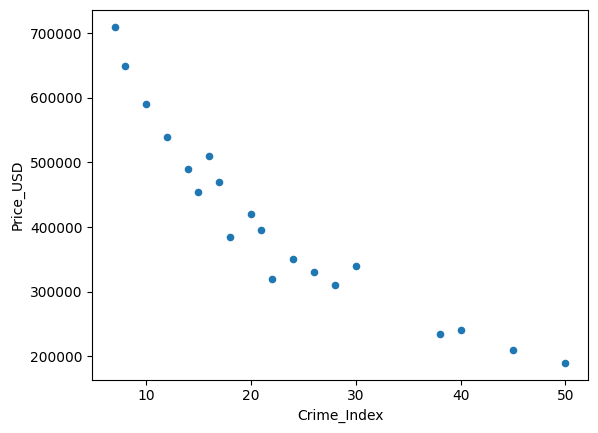

In [19]:
df.plot.scatter('Crime_Index', 'Price_USD')

#Conduct Train/Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

#Define and train the model

In [21]:
model = ExplainableBoostingRegressor()
model.fit(X_train,y_train)

ExplainableBoostingRegressor()

#Make predictions and evaluate metrics

In [22]:
y_pred = model.predict(X_test)

In [28]:
r2 = r2_score(y_test, y_pred)
print("R²:", r2)

R²: 0.9241893340395215


#Visualize the Global Features

In [26]:
show(model.explain_global())
